In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
import os
for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for f in files:
        if 'olist' in f.lower():
            print(os.path.join(root, f))

/content/drive/MyDrive/olist_customers_dataset.csv.zip
/content/drive/MyDrive/olist_orders_dataset.csv.zip
/content/drive/MyDrive/olist_order_payments_dataset.csv.zip


In [ ]:
import zipfile
import os

files_to_unzip = [
    '/content/drive/MyDrive/olist_customers_dataset.csv.zip',
    '/content/drive/MyDrive/olist_orders_dataset.csv.zip',
    '/content/drive/MyDrive/olist_order_payments_dataset.csv.zip'
]

extract_path = '/content/drive/MyDrive/'

for zip_path in files_to_unzip:
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_path)

print("Done. Checking extracted files:")
for f in os.listdir(extract_path):
    if f.endswith('.csv'):
        print(f)

Done. Checking extracted files:
olist_customers_dataset.csv
olist_orders_dataset.csv
olist_order_payments_dataset.csv


In [ ]:
import pandas as pd

orders = pd.read_csv('/content/drive/MyDrive/olist_orders_dataset.csv')
payments = pd.read_csv('/content/drive/MyDrive/olist_order_payments_dataset.csv')
customers = pd.read_csv('/content/drive/MyDrive/olist_customers_dataset.csv')

print("Orders:", orders.shape)
print("Payments:", payments.shape)
print("Customers:", customers.shape)

print(orders.head())

Orders: (99441, 8)
Payments: (103886, 5)
Customers: (99441, 5)
                           order_id                       customer_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  9ef432eb6251297304e76186b10a928d   
1  53cdb2fc8bc7dce0b6741e2150273451  b0830fb4747a6c6d20dea0b8c802d7ef   
2  47770eb9100c2d0c44946d9cf07ec65d  41ce2a54c0b03bf3443c3d931a367089   
3  949d5b44dbf5de918fe9c16f97b45f8a  f88197465ea7920adcdbec7375364d82   
4  ad21c59c0840e6cb83a9ceb5573f8159  8ab97904e6daea8866dbdbc4fb7aad2c   

  order_status order_purchase_timestamp    order_approved_at  \
0    delivered      2017-10-02 10:56:33  2017-10-02 11:07:15   
1    delivered      2018-07-24 20:41:37  2018-07-26 03:24:27   
2    delivered      2018-08-08 08:38:49  2018-08-08 08:55:23   
3    delivered      2017-11-18 19:28:06  2017-11-18 19:45:59   
4    delivered      2018-02-13 21:18:39  2018-02-13 22:20:29   

  order_delivered_carrier_date order_delivered_customer_date  \
0          2017-10-04 19:55:00           2017-10-

In [ ]:
# Merge orders with customers to get customer_unique_id
orders_customers = orders.merge(customers, on='customer_id', how='left')

# Merge with payments to get payment_value (sum in case of split payments)
payments_summed = payments.groupby('order_id')['payment_value'].sum().reset_index()
merged = orders_customers.merge(payments_summed, on='order_id', how='left')

# Keep only what we need
rfm_data = merged[['order_id', 'customer_unique_id', 'order_purchase_timestamp', 'payment_value', 'order_status']].copy()

print(rfm_data.shape)
print(rfm_data.head())
print()
print("Missing values:")
print(rfm_data.isnull().sum())

(99441, 5)
                           order_id                customer_unique_id  \
0  e481f51cbdc54678b7cc49136f2d6af7  7c396fd4830fd04220f754e42b4e5bff   
1  53cdb2fc8bc7dce0b6741e2150273451  af07308b275d755c9edb36a90c618231   
2  47770eb9100c2d0c44946d9cf07ec65d  3a653a41f6f9fc3d2a113cf8398680e8   
3  949d5b44dbf5de918fe9c16f97b45f8a  7c142cf63193a1473d2e66489a9ae977   
4  ad21c59c0840e6cb83a9ceb5573f8159  72632f0f9dd73dfee390c9b22eb56dd6   

  order_purchase_timestamp  payment_value order_status  
0      2017-10-02 10:56:33          38.71    delivered  
1      2018-07-24 20:41:37         141.46    delivered  
2      2018-08-08 08:38:49         179.12    delivered  
3      2017-11-18 19:28:06          72.20    delivered  
4      2018-02-13 21:18:39          28.62    delivered  

Missing values:
order_id                    0
customer_unique_id          0
order_purchase_timestamp    0
payment_value               1
order_status                0
dtype: int64


In [ ]:
# Drop the 1 row with missing payment value
rfm_clean = rfm_data.dropna(subset=['payment_value']).copy()

# Convert timestamp to datetime
rfm_clean['order_purchase_timestamp'] = pd.to_datetime(rfm_clean['order_purchase_timestamp'])

# Check order_status values to decide what to exclude
print(rfm_clean['order_status'].value_counts())



order_status
delivered      96477
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [ ]:
rfm_final = rfm_clean[rfm_clean['order_status'] == 'delivered'].copy()

print("Final row count:", rfm_final.shape)
print("Date range:", rfm_final['order_purchase_timestamp'].min(), "to", rfm_final['order_purchase_timestamp'].max())
print("Unique customers:", rfm_final['customer_unique_id'].nunique())

Final row count: (96477, 5)
Date range: 2016-10-03 09:44:50 to 2018-08-29 15:00:37
Unique customers: 93357


In [ ]:
import datetime as dt

# Reference date = 1 day after the last order in the dataset
reference_date = rfm_final['order_purchase_timestamp'].max() + dt.timedelta(days=1)

rfm_table = rfm_final.groupby('customer_unique_id').agg(
    recency=('order_purchase_timestamp', lambda x: (reference_date - x.max()).days),
    frequency=('order_id', 'count'),
    monetary=('payment_value', 'sum')
).reset_index()

print(rfm_table.shape)
print(rfm_table.head(10))
print()
print(rfm_table.describe())

(93357, 4)
                 customer_unique_id  recency  frequency  monetary
0  0000366f3b9a7992bf8c76cfdf3221e2      112          1    141.90
1  0000b849f77a49e4a4ce2b2a4ca5be3f      115          1     27.19
2  0000f46a3911fa3c0805444483337064      537          1     86.22
3  0000f6ccb0745a6a4b88665a16c9f078      321          1     43.62
4  0004aac84e0df4da2b147fca70cf8255      288          1    196.89
5  0004bd2a26a76fe21f786e4fbd80607f      146          1    166.98
6  00050ab1314c0e55a6ca13cf7181fecf      132          1     35.38
7  00053a61a98854899e70ed204dd4bafe      183          1    419.18
8  0005e1862207bf6ccc02e4228effd9a0      543          1    150.12
9  0005ef4cd20d2893f0d9fbd94d3c0d97      170          1    129.76

            recency     frequency      monetary
count  93357.000000  93357.000000  93357.000000
mean     237.936673      1.033420    165.198772
std      152.584315      0.209099    226.314579
min        1.000000      1.000000      9.590000
25%      114.000000   

In [ ]:
import sqlite3

conn = sqlite3.connect('/content/olist_rfm.db')
rfm_table.to_sql('rfm_raw', conn, if_exists='replace', index=False)

cursor = conn.cursor()
cursor.execute("SELECT COUNT(*) FROM rfm_raw")
print("Rows in table:", cursor.fetchone()[0])

Rows in table: 93357


In [ ]:
rfm_scoring_query = """
WITH scored AS (
    SELECT
        customer_unique_id,
        recency,
        frequency,
        monetary,
        NTILE(5) OVER (ORDER BY recency DESC) AS r_score,
        NTILE(5) OVER (ORDER BY frequency ASC) AS f_score,
        NTILE(5) OVER (ORDER BY monetary ASC) AS m_score
    FROM rfm_raw
)
SELECT * FROM scored
"""

rfm_scored = pd.read_sql_query(rfm_scoring_query, conn)
print(rfm_scored.head(10))
print()
print(rfm_scored[['r_score', 'f_score', 'm_score']].describe())

                 customer_unique_id  recency  frequency  monetary  r_score  \
0  3f4f614c632af7fc7508462a7cb55ac2      695          1     18.62        1   
1  2f64e403852e6893ae37485d5fcacdaf      695          1     39.09        1   
2  87776adb449c551e74c13fc34f036105      695          1     40.95        1   
3  14359ea0c7a105749c0a56478825b015      695          1     44.23        1   
4  61db744d2f835035a5625b59350c6b63      695          1     53.73        1   
5  f922896769e9517ea3c630f3c8de86d0      695          1     62.33        1   
6  cd5a5843d35eebdf90368bf24d4a04cf      695          1     65.50        1   
7  df2988ba3ed226b10521a0e4da849b61      695          1     86.88        1   
8  10e89fd8e5c745f81bec101207ba4d7d      695          1     92.27        1   
9  f176923a0a4ab546c7287791ccb82193      695          1    101.44        1   

   f_score  m_score  
0        1        1  
1        1        1  
2        1        1  
3        1        1  
4        1        1  
5        

In [ ]:
# Combine scores into a single RFM string and total score
rfm_scored['rfm_score'] = rfm_scored['r_score'].astype(str) + rfm_scored['f_score'].astype(str) + rfm_scored['m_score'].astype(str)
rfm_scored['rfm_total'] = rfm_scored['r_score'] + rfm_scored['f_score'] + rfm_scored['m_score']

def segment_customer(row):
    if row['r_score'] >= 4 and row['f_score'] >= 4 and row['m_score'] >= 4:
        return 'Champions'
    elif row['r_score'] >= 4 and row['f_score'] <= 2:
        return 'New Customers'
    elif row['r_score'] <= 2 and row['f_score'] >= 4:
        return 'At Risk'
    elif row['r_score'] <= 2 and row['f_score'] <= 2 and row['m_score'] <= 2:
        return 'Lost'
    elif row['rfm_total'] >= 10:
        return 'Loyal Customers'
    else:
        return 'Needs Attention'

rfm_scored['segment'] = rfm_scored.apply(segment_customer, axis=1)

print(rfm_scored['segment'].value_counts())

segment
Needs Attention    18565
Lost               15414
Loyal Customers    15354
Champions          15164
At Risk            14514
New Customers      14346
Name: count, dtype: int64


In [ ]:
segment_summary = rfm_scored.merge(rfm_table[['customer_unique_id', 'monetary']], on='customer_unique_id', suffixes=('', '_raw'))

revenue_by_segment = segment_summary.groupby('segment').agg(
    customer_count=('customer_unique_id', 'count'),
    total_revenue=('monetary', 'sum'),
    avg_revenue_per_customer=('monetary', 'mean')
).sort_values('total_revenue', ascending=False)

print(revenue_by_segment)

                 customer_count  total_revenue  avg_revenue_per_customer
segment                                                                 
Champions                 15164     4696728.55                309.728868
At Risk                   14514     4490311.66                309.377956
Loyal Customers           15354     2974687.60                193.740237
Needs Attention           18565     1614995.69                 86.991419
Lost                      15414      859081.28                 55.733832
New Customers             14346      786656.99                 54.834587


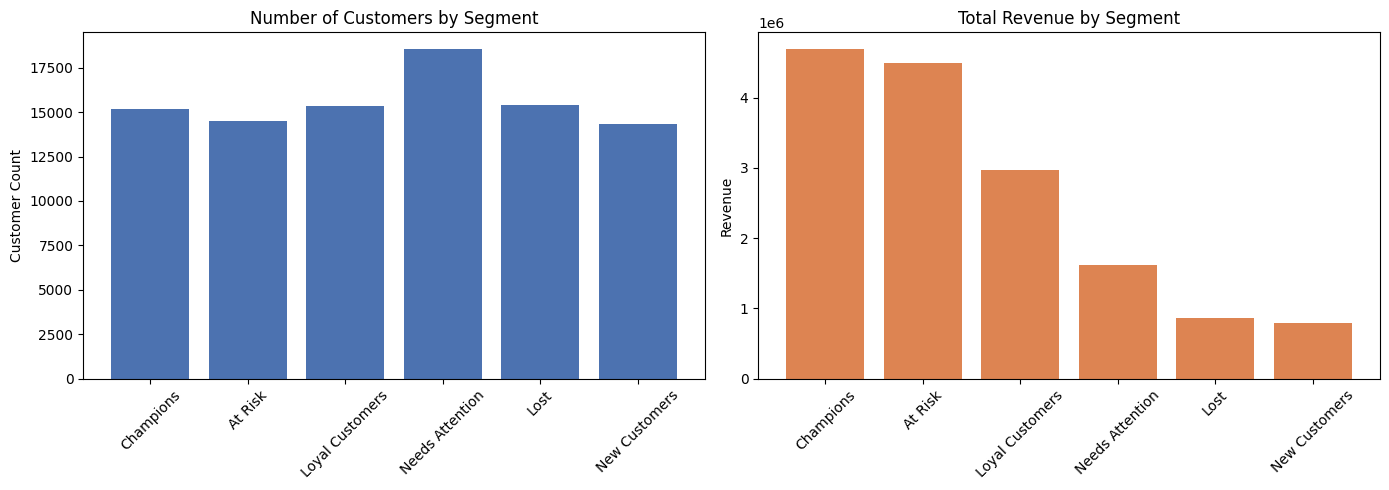

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Chart 1: Customer count by segment
axes[0].bar(revenue_by_segment.index, revenue_by_segment['customer_count'], color='#4C72B0')
axes[0].set_title('Number of Customers by Segment')
axes[0].set_ylabel('Customer Count')
axes[0].tick_params(axis='x', rotation=45)

# Chart 2: Revenue by segment
axes[1].bar(revenue_by_segment.index, revenue_by_segment['total_revenue'], color='#DD8452')
axes[1].set_title('Total Revenue by Segment')
axes[1].set_ylabel('Revenue')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/content/rfm_segments_chart.png', dpi=150)
plt.show()

In [ ]:
from google.colab import files
files.download('/content/rfm_segments_chart.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Save RFM scored table and segment summary as CSVs
rfm_scored.to_csv('/content/customer_rfm_scores.csv', index=False)
revenue_by_segment.to_csv('/content/segment_revenue_summary.csv')

files.download('/content/customer_rfm_scores.csv')
files.download('/content/segment_revenue_summary.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [16]:
sql1 = """-- RFM scoring using NTILE window functions
WITH scored AS (
    SELECT
        customer_unique_id,
        recency,
        frequency,
        monetary,
        NTILE(5) OVER (ORDER BY recency DESC) AS r_score,
        NTILE(5) OVER (ORDER BY frequency ASC) AS f_score,
        NTILE(5) OVER (ORDER BY monetary ASC) AS m_score
    FROM rfm_raw
)
SELECT * FROM scored;"""

with open('/content/01_rfm_scoring.sql', 'w') as f:
    f.write(sql1)

print("File created")

File created


In [17]:
from google.colab import files
files.download('/content/01_rfm_scoring.sql')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
sql2 = """-- Revenue contribution by RFM segment
-- Note: segment labels (Champions, At Risk, etc.) were assigned in Python
-- based on r_score, f_score, m_score thresholds from 01_rfm_scoring.sql

SELECT
    segment,
    COUNT(customer_unique_id) AS customer_count,
    SUM(monetary) AS total_revenue,
    AVG(monetary) AS avg_revenue_per_customer
FROM rfm_segmented
GROUP BY segment
ORDER BY total_revenue DESC;"""

with open('/content/02_segment_revenue.sql', 'w') as f:
    f.write(sql2)

print("File created")

File created


In [19]:
files.download('/content/02_segment_revenue.sql')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>